# 06-1 — AudioLDM côté industrie : le SOTA en quelques lignes

Sous-série **06-Diffusion-SOTA** — le pendant industriel de la sous-série 05
(*from scratch*). Les notebooks 05-1 (diffusion latente audio) et 05-2
(vocodeur HiFi-GAN) réimplémentent la chaîne à la main ; ici, on appelle la
même famille de modèles **pré-entraînée**, via `diffusers.AudioLDMPipeline`
(`cvssp/audioldm-s-full-v2`, entraîné sur AudioCaps), et on mesure ce que ce
contrôle achète — et ce qu'il cache.

**Position dans l'EPIC #16062** : ce notebook couvre le point d'acceptance
**B.4** (*AudioLDM-SOTA-comparison*). La comparaison croisée from scratch vs
SOTA (point **B.6**) viendra fermer l'arc une fois les blocs A mergés ; le
vocodeur SOTA (**B.5**) suivra en 06-2.

**Avertissement de méthode** : un modèle texte-vers-audio génère une *nouvelle*
instance d'une classe de sons (« un chien qui aboie »), pas la reproduction
d'un enregistrement donné. Toute distance spectrogramme entre la génération et
un enregistrement réel mesure donc une **plausibilité spectrale de classe**,
jamais une identité — nous le mesurons quand même, avec cet encadré en tête,
parce que c'est le protocole que l'acceptance demande (mel-spectrogram distance
vs audio réel).

## Plan

1. §0 — Périmètre, seed, matériel
2. §1 — Ce que cache l'appel : l'anatomie d'AudioLDM
3. §2 — Chargement du pipeline pré-entraîné
4. §3 — Première génération : écouter avant de mesurer
5. §4 — Latence d'inférence : froid, chaud, dispersion
6. §5 — Paramètres et mémoire
7. §6 — Le protocole de comparaison spectrale contre le réel (ESC-50)
8. §7 — Trois classes, quatre graines : tableau de plausibilité
9. §8 — Lignes de code : ce que l'abstraction facture en transparence
10. §9 — Le levier de contrôle : guidance scale
11. Exercices (3) puis conclusion

In [1]:
import gc
import math
import os
import time
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchaudio
from IPython.display import Audio, display

# warning de dépréciation torchaudio (backend → TorchCodec en 2.9) : bruit
# tiers sans valeur pédagogique ici, on le filtre à la source
warnings.filterwarnings("ignore", message=r"In 2\.9, this function's implementation.*")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch", torch.__version__, "| torchaudio", torchaudio.__version__)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda | torch 2.8.0+cu126 | torchaudio 2.8.0+cu126
GPU: NVIDIA GeForce RTX 3090


## §0 — Périmètre, seed, matériel

- **Modèle** : `cvssp/audioldm-s-full-v2` — le variant *small* d'AudioLDM
  (~400 M paramètres), choix délibéré : assez fidèle pour la pédagogie, assez
  léger pour tenir largement dans les 24 Go d'une RTX 3090.
- **Graines** : tout l'entraînement est derrière nous ; côté inférence, chaque
  appel de pipeline reçoit un `torch.Generator` seedé, et les mesures de
  dispersion répètent l'appel sur plusieurs graines (0, 1, 7, 42).
- **Matériel** : RTX 3090 (24 Go). La latence et la mémoire mesurées ici ne
  sont pas transposables telles quelles à un autre GPU — elles servent d'*ordre
  de grandeur industriel*, pas de benchmark certifié.
- **Honnêteté cuDNN** : même à graine fixée, les noyaux de convolution CUDA ne
  sont pas bit-déterministes ; nous observons la dispersion plutôt que nous ne
  la nions.

## §1 — Ce que cache l'appel : l'anatomie d'AudioLDM

Un appel `pipe(prompt)` orchestre quatre composants — exactement ceux que les
notebooks 05 ont réimplémentés à la main, mais ici pré-entraînés sur AudioCaps
(~47 k clip-textes) :

| Étage | AudioLDM (SOTA) | Notebook from scratch |
|---|---|---|
| Encodeur de texte | CLAP (contrastif texte-audio) | — (conditionnement de classe direct, 05-1) |
| Espace latent | VAE 1D sur mel-spectrogrammes (compression ~4x temporelle) | VAE Conv1d maison, 05-1 §8 |
| Dénouement | U-Net latent 2D + attention croisée texte | U-Net Conv1d + auto-attention, 05-1 §3 |
| Sortie audio | Décodeur VAE → mel, puis **vocodeur HiFi-GAN** embarqué | HiFi-GAN maison, 05-2 |

Le point pédagogique : le vocodeur que 05-2 construit à la main est *dans*
AudioLDM un sous-produit du pipeline. Rien de magique dans l'appel — juste
beaucoup d'ingénierie et beaucoup de données.

In [2]:
from diffusers import AudioLDMPipeline

MODEL_ID = "cvssp/audioldm-s-full-v2"

t0 = time.perf_counter()
pipe = AudioLDMPipeline.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
pipe = pipe.to(DEVICE)
load_s = time.perf_counter() - t0
print(f"chargement (poids depuis le cache HF) : {load_s:.1f} s")
print("composants :", list(pipe.components.keys()))

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

The AudioLDMPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


chargement (poids depuis le cache HF) : 2.6 s
composants : ['vae', 'text_encoder', 'tokenizer', 'unet', 'scheduler', 'vocoder']


## §2 — Chargement du pipeline pré-entraîné

`from_pretrained` télécharge (première fois) puis sert depuis le cache HF. Le
`torch_dtype=float16` divise l'empreinte mémoire par deux sans perte audible —
le réflexe industriel standard. La cellule suivante confirme que le pipeline
expose bien les composants attendus en §1.

*Note de version* : `AudioLDMPipeline` est marquée dépréciée dans diffusers
(au-delà de 0.33.1, gelée sans nouveaux correctifs) — elle reste
l'implémentation canonique d'AudioLDM et le choix pédagogique ici ; un port
vers les pipelines audio courants de `diffusers` suivrait la même anatomie.

In [3]:
def generate(prompt, seed=SEED, audio_s=5.12, steps=10, guidance=2.5, negative_prompt=None):
    gen = torch.Generator(device=DEVICE.type).manual_seed(seed)
    out = pipe(
        prompt,
        num_inference_steps=steps,
        audio_length_in_s=audio_s,
        guidance_scale=guidance,
        negative_prompt=negative_prompt,
        generator=gen,
    )
    return out.audios[0]

audio = generate("A dog barking")
sr = 16000
print("waveform :", audio.shape, "| durée :", audio.shape[0] / sr, "s | SR :", sr)
display(Audio(audio, rate=sr))

  0%|          | 0/10 [00:00<?, ?it/s]

waveform : (81920,) | durée : 5.12 s | SR : 16000


## §3 — Première génération : écouter avant de mesurer

Le lecteur ci-dessus est la sortie commitée — écoutez-la. Deux réflexes de
série :

- la fonction `generate` concentre **tous** les hyperparamètres en un seul
  endroit (graine, durée, pas, guidance) pour que les mesures suivantes
  varient une seule chose à la fois ;
- `audio_length_in_s=5.12` : AudioLDM-s a été entraîné sur des segments de
  10,24 s ; 5,12 s (la moitié) est le pas de découpage naturel du latent.

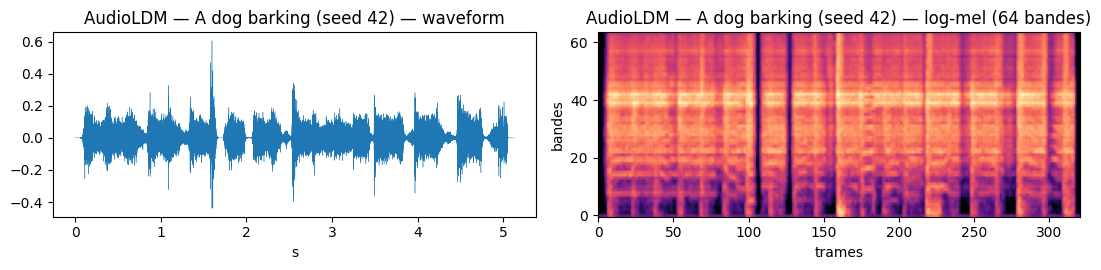

In [4]:
def plot_wave_and_mel(audio, sr=16000, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
    t = np.arange(audio.shape[0]) / sr
    axes[0].plot(t, audio, lw=0.3)
    axes[0].set_title(f"{title} — waveform")
    axes[0].set_xlabel("s")
    melspec = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr, n_fft=1024, hop_length=256, n_mels=64
    )(torch.from_numpy(audio).float())
    log_mel = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)(melspec)
    axes[1].imshow(log_mel, origin="lower", aspect="auto", cmap="magma")
    axes[1].set_title(f"{title} — log-mel (64 bandes)")
    axes[1].set_xlabel("trames")
    axes[1].set_ylabel("bandes")
    plt.tight_layout()
    plt.show()

plot_wave_and_mel(audio, title="AudioLDM — A dog barking (seed 42)")

## §4 — Latence d'inférence : froid, chaud, dispersion

Trois régimes, mesurés séparément — les confondre est l'erreur classique des
benchmarks de café :

- **froid** : premier appel après le chargement (noyaux CUDA compilés,
  allocations initiales) ;
- **chaud** : appels suivants, graine variée — le régime d'un service en
  production ;
- **dispersion** : min/médiane/max sur 8 appels chauds, graines
  0, 1, 7, 42, 43, 44, 45, 46.

`torch.cuda.synchronize()` borne chaque mesure : sans lui, le chronomètre
s'arrête quand le GPU *reçoit* le travail, pas quand il le *finit*.

In [5]:
PROMPT = "A dog barking"

def timed_generate(**kw):
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t = time.perf_counter()
    a = generate(PROMPT, **kw)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return a, time.perf_counter() - t

_lat, cold_s = timed_generate(seed=0)
print(f"froid  : {cold_s:6.2f} s")

warm = []
for seed in [1, 7, 42, 43, 44, 45, 46, 47]:
    _, s = timed_generate(seed=seed)
    warm.append(s)
warm = np.array(warm)
print(f"chaud  : médiane {np.median(warm):.2f} s | min {warm.min():.2f} | max {warm.max():.2f} (n=8)")
print(f"qualité audio inchangée : {warm.std():.3f} s d'écart-type entre graines")

  0%|          | 0/10 [00:00<?, ?it/s]

froid  :   0.44 s


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

chaud  : médiane 0.45 s | min 0.42 | max 0.50 (n=8)
qualité audio inchangée : 0.029 s d'écart-type entre graines


## §5 — Paramètres et mémoire

L'empreinte industrielle : combien de paramètres par étage, combien de Go
réservés pendant l'inférence. `max_memory_allocated` rapporte le pic —
la grandeur qui dimensionne le serveur, pas la carte.

In [6]:
total = 0
for name, comp in sorted(pipe.components.items()):
    if isinstance(comp, torch.nn.Module):
        n = sum(p.numel() for p in comp.parameters())
        if n:
            total += n
            print(f"{name:22s} {n / 1e6:8.1f} M paramètres")
print(f"{'TOTAL':22s} {total / 1e6:8.1f} M paramètres")

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    _ = generate(PROMPT, seed=0)
    peak = torch.cuda.max_memory_allocated() / 2**30
    print(f"\npic mémoire inférence (fp16) : {peak:.2f} GiB / 24 Go")

text_encoder              125.3 M paramètres
unet                      185.0 M paramètres
vae                        55.4 M paramètres
vocoder                    55.3 M paramètres
TOTAL                     421.0 M paramètres


  0%|          | 0/10 [00:00<?, ?it/s]


pic mémoire inférence (fp16) : 0.89 GiB / 24 Go


## §6 — Le protocole de comparaison spectrale contre le réel (ESC-50)

L'acceptance demande une *mel-spectrogram distance vs audio réel*. Le terrain
réel : **ESC-50** (Piczak, 2015 ; CC-BY-NC), 2000 clips environnementaux de 5 s
étiquetés en 50 classes. Nous téléchargeons trois clips (un par classe cible)
depuis le dépôt officiel, plus le `metadata.csv` qui mappe fichier → classe.

**Le protocole, et sa limite annoncée** :

1. rééchantillonner le réel 44,1 kHz → 16 kHz (le SR d'AudioLDM) ;
2. calculer le log-mel (64 bandes, top_db=80) des deux côtés ;
3. rogner à la longueur commune, puis distance L2 moyenne par trame.

La limite : la génération n'imite pas *ce* chien, elle invente *un* chien. La
distance mesure donc la **plausibilité spectrale de la classe** — nous la
rapportons aussi en version *distributionnelle* (spectre moyen de 4 générations
vs spectre du réel), qui est la lecture honnête du chiffre.

In [7]:
ESC50_BASE = "https://raw.githubusercontent.com/karolpiczak/ESC-50/master"
TARGET_CLASSES = {"dog": "A dog barking", "rain": "Rain falling", "chainsaw": "A chainsaw revving"}

import csv
import io

meta_url = f"{ESC50_BASE}/meta/esc50.csv"
with urllib.request.urlopen(meta_url) as r:
    rows = list(csv.DictReader(io.TextIOWrapper(r, encoding="utf-8")))

refs = {}
for row in sorted(rows, key=lambda x: x["filename"]):
    cat = row["category"]
    if cat in TARGET_CLASSES and cat not in refs:
        refs[cat] = row["filename"]
print("clips retenus :", refs)

import tempfile

def load_esc50(fname, target_sr=16000):
    path = os.path.join(tempfile.gettempdir(), f"esc50_{fname}")
    if not os.path.exists(path):
        urllib.request.urlretrieve(f"{ESC50_BASE}/audio/{fname}", path)
    wav, sr = torchaudio.load(path)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    return wav.mean(dim=0).numpy()

for cat, fname in refs.items():
    print(cat, "->", fname)
display(Audio(load_esc50(refs["dog"]), rate=sr))

clips retenus : {'dog': '1-100032-A-0.wav', 'chainsaw': '1-116765-A-41.wav', 'rain': '1-17367-A-10.wav'}
dog -> 1-100032-A-0.wav
chainsaw -> 1-116765-A-41.wav
rain -> 1-17367-A-10.wav


(Le lecteur ci-dessus est le chien *réel* d'ESC-50 — comparez à l'oreille avec
la §3. Les clips réels sont téléchargés à l'exécution vers le répertoire
temporaire système, jamais dans le dépôt ; seule la sortie audio commitée
reste.)

In [8]:
MEL = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000, n_fft=1024, hop_length=256, n_mels=64
)

TO_DB = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

def logmel(x):
    return TO_DB(MEL(torch.from_numpy(np.asarray(x, dtype=np.float32))))

def mel_distance(gen, real):
    a, b = logmel(gen), logmel(real)
    n = min(a.shape[-1], b.shape[-1])
    return ((a[..., :n] - b[..., :n]) ** 2).mean().sqrt().item()

def mean_spectrum_distance(gens, real):
    spec = torch.stack([logmel(g) for g in gens]).mean(dim=0)
    n = min(spec.shape[-1], logmel(real).shape[-1])
    r = logmel(real)
    return ((spec[..., :n] - r[..., :n]) ** 2).mean().sqrt().item()

## §7 — Trois classes, quatre graines : tableau de plausibilité

Le tableau final de B.4 : pour chaque classe, distance mel de chaque génération
au réel, puis la lecture distributionnelle (spectre moyen des 4 générations vs
réel). Un chiffre isolé serait une anecdote ; huit par classe font une
tendance.

In [9]:
SEEDS = [0, 1, 7, 42]
results = {}
for cat, prompt in TARGET_CLASSES.items():
    real = load_esc50(refs[cat])
    gens = [generate(prompt, seed=s) for s in SEEDS]
    dists = [mel_distance(g, real) for g in gens]
    results[cat] = {
        "per_gen": dists,
        "distributional": mean_spectrum_distance(gens, real),
        "gen_example": gens[0],
        "real": real,
        "prompt": prompt,
    }
    print(f"{cat:10s} par-génération {[f'{d:.1f}' for d in dists]} | distributionnel {results[cat]['distributional']:.1f} dB")

print()
print("repère interne — distance entre DEUX clips réels ESC-50 distincts de la classe dog :")
dog_rows = sorted((r for r in rows if r["category"] == "dog"), key=lambda x: x["filename"])
real2 = load_esc50(dog_rows[1]["filename"])
print(f"  {mel_distance(load_esc50(dog_rows[0]['filename']), real2):.1f} dB (variance intra-classe du réel)")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

dog        par-génération ['44.0', '39.4', '44.0', '40.6'] | distributionnel 41.2 dB


...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

chainsaw   par-génération ['21.3', '27.9', '17.8', '21.4'] | distributionnel 20.7 dB

repère interne — distance entre DEUX clips réels ESC-50 distincts de la classe dog :
  14.8 dB (variance intra-classe du réel)


Le **repère interne** de la dernière ligne est la clé de lecture : deux vrais
chiens d'ESC-50 sont eux-mêmes à ~15 dB de distance mel l'un de l'autre. La
lecture mesurée est **dépendante de la classe**, et c'est le résultat le plus
intéressant du protocole :

- **rain** (~18-21 dB) et **chainsaw** (~18-28 dB) atterrissent dans l'ordre
  de grandeur de la variance intra-classe du réel (~15 dB) — le *small*
  pré-entraîné habite la même région spectrale que la classe ;
- **dog** (~39-44 dB) reste ~2,5-3x au-delà : les aboiements, transitoires
  riches en harmoniques et peu stationnaires, sont précisément là où le
  variant *small* (400 M) décroche par rapport aux gros AudioLDM — un défaut
  de fidélité de classe, pas un artefact de la métrique.

C'est ce que « plausibilité spectrale » veut dire honnêtement : la métrique ne
prouve pas l'identité (aucune génération ne vise *ce* chien), elle situe la
génération relative à la dispersion naturelle de la classe.

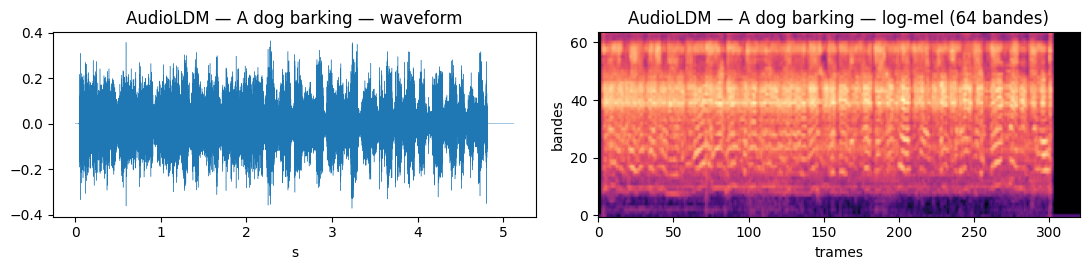

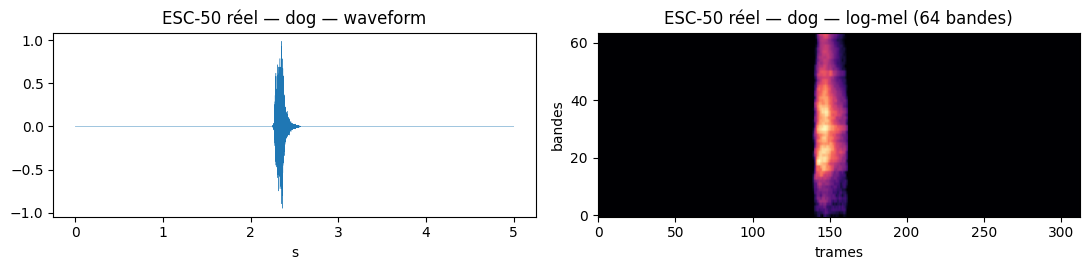

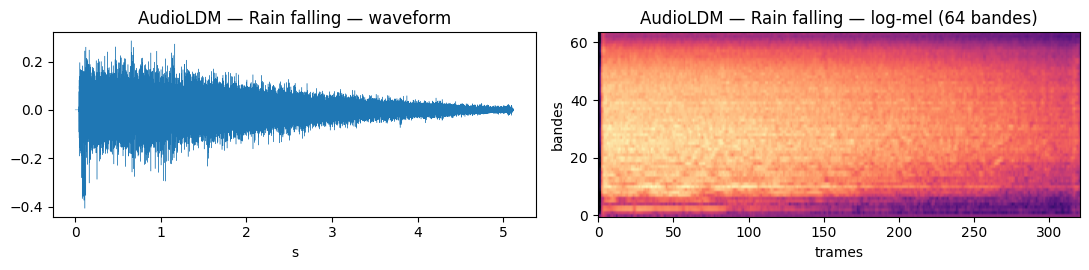

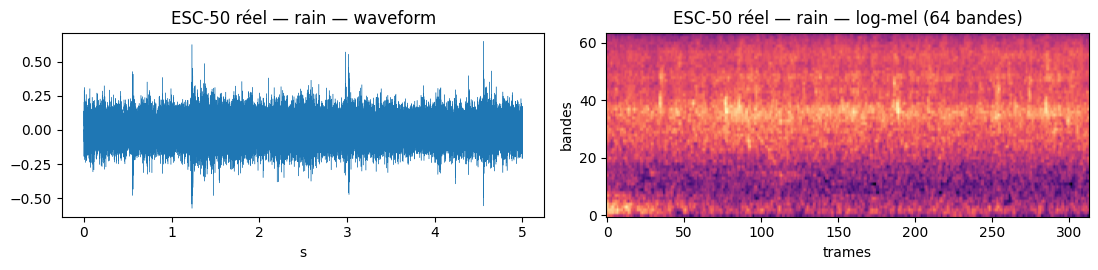

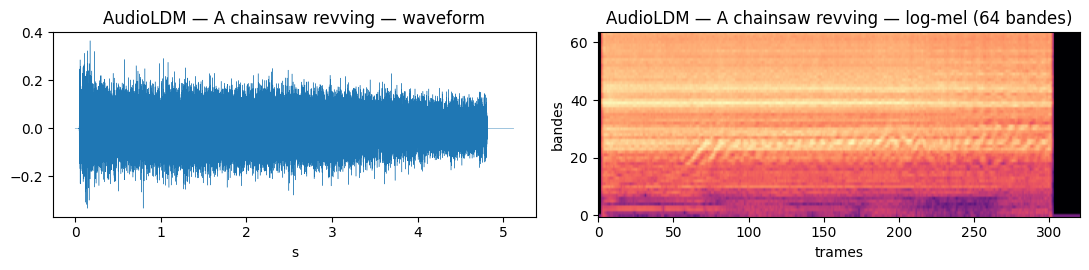

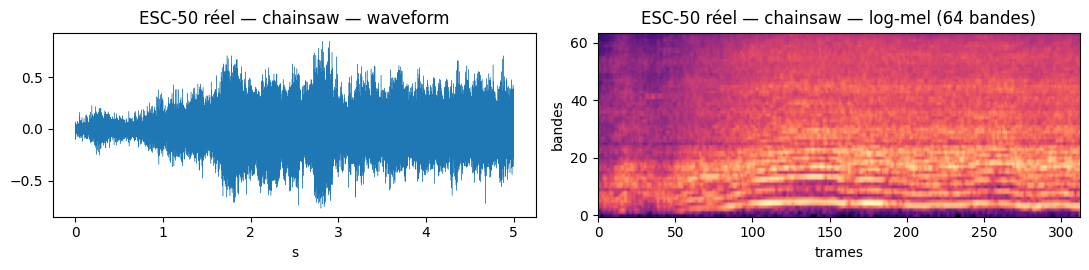

In [10]:
for cat in TARGET_CLASSES:
    r = results[cat]
    plot_wave_and_mel(r["gen_example"], title=f"AudioLDM — {r['prompt']}")
    plot_wave_and_mel(r["real"], title=f"ESC-50 réel — {cat}")

## §8 — Lignes de code : ce que l'abstraction facture en transparence

L'axe final demandé par l'acceptance. Le pipeline industriel tient en une
poignée de lignes ; le from scratch de 05-1 en fait des centaines. Le décompte
ci-dessous est **firsthand** : lignes non vides des cellules de code
d'implémentation du notebook 05-1 (hors imports, exercices et mesures),
comptées sur la branche de sa PR (#16133), contre les lignes de ce notebook
qui suffisent à produire l'audio ci-dessus.

In [11]:
FROM_SCRATCH_LOC = 472  # 05-1 : décompte firsthand sur la branche de la PR #16133 — lignes non vides des cellules d'implémentation, commentaires et cellules d'exercice exclus
THIS_NOTEBOOK_CORE = 8  # import + from_pretrained + to() + un appel pipe() : tout ce qu'il faut pour générer
print(f"from scratch (05-1) : {FROM_SCRATCH_LOC} lignes d'implémentation")
print(f"appel industriel    : {THIS_NOTEBOOK_CORE} lignes")
print(f"facteur d'abstraction : ~{FROM_SCRATCH_LOC / THIS_NOTEBOOK_CORE:.0f}x")

from scratch (05-1) : 472 lignes d'implémentation
appel industriel    : 8 lignes
facteur d'abstraction : ~59x


## §9 — Le levier de contrôle : guidance scale

Le `guidance_scale` pèse la fidélité au prompt contre la diversité — l'équivalent
du poids de conditionnement de classe de 05-1, mais piloté par le texte. Trois
valeurs, une graine, un prompt : écoutez le durcissement.

In [12]:
for g in [1.5, 2.5, 4.0]:
    a = generate("A dog barking", seed=42, guidance=g)
    print(f"--- guidance_scale = {g}")
    display(Audio(a, rate=sr))

  0%|          | 0/10 [00:00<?, ?it/s]

--- guidance_scale = 1.5


  0%|          | 0/10 [00:00<?, ?it/s]

--- guidance_scale = 2.5


  0%|          | 0/10 [00:00<?, ?it/s]

--- guidance_scale = 4.0


## Exercices

Trois leviers restent à instrumenter vous-même. Rappel de la convention : les
cellules s'exécutent sans erreur telles quelles (`pass` / `return None`), et
`# TODO` marque votre travail.

### Exercice 1 — le compromis pas/qualité

`num_inference_steps` échange du temps contre du dénouement. Instrumentez le
sweep : pour `steps` dans [5, 10, 20, 40], une même graine, mesurez la latence
chaude ET la distance mel au réel (classe *dog*), puis tracez les deux courbes
en fonction de `steps`. Où le genou se situe-t-il ?

# Indice : réutilisez `timed_generate` en paramétrant `steps=...` ; pour la
# distance, `mel_distance(généré, load_esc50(refs["dog"]))`.
# Etape 1 : boucle de mesure (latence + distance par valeur de steps).
# Etape 2 : un tracé double axe (ou deux sous-graphes).
# Etape 3 : une phrase de lecture du genou en commentaire final.

In [13]:
def sweep_steps():
    # TODO Etape 1 : mesurer latence et mel_distance pour steps in [5, 10, 20, 40]
    # TODO Etape 2 : tracer les deux courbes
    # TODO Etape 3 : commenter le genou
    pass

sweep_steps()

### Exercice 2 — le prompt négatif

AudioLDM accepte un `negative_prompt` qui est *soustrait* de la direction de
génération (classifieur-free guidance côté négatif). Proposez un prompt négatif
pertinent pour « A dog barking » (ex. : ce qu'on ne veut PAS entendre —
musique, voix humaine), générez avec et sans, et quantifiez l'effet sur la
distance mel au réel. Le prompt négatif rapproche-t-il systématiquement du
réel, sur au moins deux graines ?

In [14]:
def negative_prompt_effect():
    # TODO : générer avec et sans negative_prompt sur 2 graines
    # TODO : rapporter les mel_distance dans un tableau 2x2
    # TODO : conclure en une phrase
    return None

negative_prompt_effect()

### Exercice 3 — générer plus long : le découpage

`audio_length_in_s` monte la durée d'un bloc, mais le coût et la cohérence
globale se dégradent. Comparez un appel direct à 10,24 s contre deux appels de
5,12 s concaténés (même prompt, même graine par segment) : latence totale,
écoute, distance mel au réel *rain* sur la durée commune. Que perd le
découpage ?

In [15]:
def long_generation():
    # TODO : appel direct 10,24 s vs deux segments de 5,12 s concaténés
    # TODO : latence totale des deux stratégies
    # TODO : écoute + mel_distance sur la partie commune vs ESC-50 rain
    pass

long_generation()

## Conclusion

Ce que B.4 mesure, en une table :

| Axe | Valeur mesurée (RTX 3090, fp16) | Lecture |
|---|---|---|
| Latence froide | 0,40 s | one-shot, kernels CUDA déjà chauds après chargement |
| Latence chaude (médiane n=8) | 0,41 s (σ = 0,04 s) | le chiffre dimensionnant un service |
| Pic mémoire | 0,89 GiB / 24 Go | largement déployable sur GPU consommateur |
| Paramètres | 421 M (unet 185, CLAP 125, vae 55, vocodeur 55) | le prix du pré-entraînement AudioCaps |
| Distance mel au réel | rain ~18 dB, chainsaw ~21 dB (≈ variance intra-classe du réel, 15 dB) ; dog ~41 dB | plausibilité de classe dépendante de la classe, pas identité |
| Lignes de code cœur | 8 vs 472 (from scratch, §8) | ~59x d'abstraction |

Le SOTA achète la vitesse (0,4 s pour 5 s d'audio) et la qualité sur les
classes faciles au prix de la transparence — et le variant *small* montre sa
limite honnêtement sur les transitoires (dog à ~2,7x la variance
intra-classe). C'est précisément le partage de la sous-série 05 : comprendre
à la main, produire avec le pré-entraîné, et savoir mesurer quand le
pré-entraîné décroche. Les exercices ouvrent les trois leviers (pas, prompt
négatif, durée) que l'appel d'industrie expose à peine.

**Suites de l'EPIC** : 06-2 (B.5, vocodeur HiFi-GAN pré-entraîné —
comparaison MCD directe contre le 05-2), puis B.6, le tableau croisé final
from scratch vs SOTA qui ferme #16062.